In [87]:
from json import load
import os, sys
import pandas as pd
import numpy as np
from pathlib import Path
import logging
import torch

PROJECT_DIR = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER"
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
    
import multiomic_transformer.utils.experiment_loader as experiment_loader

GROUND_TRUTH_DIR = Path(PROJECT_DIR, "data/ground_truth_files")
OTHER_METHOD_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.GRN_BENCHMARKING.MOELLER/testing_bear_grn/INFERRED.GRNS")
    
logging.basicConfig(level=logging.INFO, format='%(message)s')

In [88]:
def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()

    return df

def load_vocab(selected_experiment_dir):
    id2name = torch.load(selected_experiment_dir / "tf_tg_vocab_id2name.pt", map_location="cpu")
    tf_names = list(id2name["tf_id2name"])
    tg_names = list(id2name["tg_id2name"])

    return tf_names, tg_names

def load_ground_truth(ground_truth_file):
    if ground_truth_file.suffix == ".csv":
        sep = ","
    elif ground_truth_file.suffix == ".tsv":
        sep="\t"
        
    ground_truth_df = pd.read_csv(ground_truth_file, sep=sep, on_bad_lines="skip", engine="python")
    
    if "chip" in ground_truth_file.name and "atlas" in ground_truth_file.name:
        ground_truth_df = ground_truth_df[["source_id", "target_id"]]

    if ground_truth_df.columns[0] != "Source" or ground_truth_df.columns[1] != "Target":
        ground_truth_df = ground_truth_df.rename(columns={ground_truth_df.columns[0]: "Source", ground_truth_df.columns[1]: "Target"})
    ground_truth_df["Source"] = ground_truth_df["Source"].astype(str).str.upper()
    ground_truth_df["Target"] = ground_truth_df["Target"].astype(str).str.upper()
        
    return ground_truth_df

def prep_gt_edges(gt_df: pd.DataFrame) -> pd.DataFrame:
    gt = gt_df[["Source", "Target"]].dropna().copy()
    gt["Source"] = gt["Source"].astype(str).str.upper()
    gt["Target"] = gt["Target"].astype(str).str.upper()
    gt = gt.drop_duplicates()
    gt["_in_gt"] = 1
    return gt

def load_other_method_grns(sample_name_list, dataset_type):
    other_method_grns = {}
    for sample_name in sample_name_list:
        logging.info(f"\nProcessing sample: {sample_name}")
        if dataset_type.lower() == "mesc":
            cell_oracle_path  = OTHER_METHOD_DIR / f"{sample_name}/CellOracle/filtered_L2_{sample_name}_out_E7.5_rep1_final_GRN.csv"
            directnet_path    = OTHER_METHOD_DIR / f"{sample_name}/DIRECTNET/{sample_name}_all_cells_Network_links.csv"
            figr_path         = OTHER_METHOD_DIR / f"{sample_name}/FigR/{sample_name}_all_cells_filtered_network.csv"
            granie_path       = OTHER_METHOD_DIR / f"{sample_name}/GRaNIE/GRN_connections_filtered_sorted_sc{sample_name}_all_cells_selected_uniq.csv"
            linger_path       = OTHER_METHOD_DIR / f"{sample_name}/LINGER/filtered_L2_{sample_name}.csv"
            pando_path        = OTHER_METHOD_DIR / f"{sample_name}/Pando/{sample_name}_all_cells_raw_network.csv"
            scenic_plus_path  = OTHER_METHOD_DIR / f"{sample_name}/SCENIC+/scenic_plus_inferred_grn_mESC_filtered_L2_{sample_name}.tsv"
            tripod_path       = OTHER_METHOD_DIR / f"{sample_name}/TRIPOD/gene_TF_highest_abs_coef.csv"
        
        elif dataset_type.lower() == "macrophage":
            if sample_name == "buffer_1":
                cell_oracle_path  = OTHER_METHOD_DIR / f"Macrophage_S1/CellOracle/Macrophase_buffer1_filtered_out_E7.5_rep1_final_GRN.csv"
                directnet_path    = OTHER_METHOD_DIR / f"Macrophage_S1/DIRECTNET/Network_links.csv"
                figr_path         = OTHER_METHOD_DIR / f"Macrophage_S1/FigR/Buffer1_filtered_network.csv"
                granie_path       = OTHER_METHOD_DIR / f"Macrophage_S1/GRaNIE/GRN_connections_filtered_sorted_scBuffer1_uniq.csv"
                linger_path       = OTHER_METHOD_DIR / f"Macrophage_S1/LINGER/cell_type_TF_gene.csv"
                pando_path        = OTHER_METHOD_DIR / f"Macrophage_S1/Pando/Macrophage_buffer1_raw_network.csv"
                scenic_plus_path  = OTHER_METHOD_DIR / f"Macrophage_S1/SCENIC+/scenic_plus_inferred_grn_macrophage_macrophage_buffer1_filtered.tsv"
                tripod_path       = OTHER_METHOD_DIR / f"Macrophage_S1/TRIPOD/gene_TF_highest_abs_coef.csv"

            elif sample_name == "buffer_2":
                cell_oracle_path  = OTHER_METHOD_DIR / f"Macrophage_S2/CellOracle/Macrophase_buffer2_filtered_out_E7.5_rep1_final_GRN.csv"
                directnet_path    = OTHER_METHOD_DIR / f"Macrophage_S2/DIRECTNET/Network_links.csv"
                figr_path         = OTHER_METHOD_DIR / f"Macrophage_S2/FigR/Buffer2_filtered_network.csv"
                granie_path       = OTHER_METHOD_DIR / f"Macrophage_S2/GRaNIE/GRN_connections_filtered_sorted_scBuffer2_uniq.csv"
                linger_path       = OTHER_METHOD_DIR / f"Macrophage_S2/LINGER/cell_type_TF_gene_buffer2.csv"
                pando_path        = OTHER_METHOD_DIR / f"Macrophage_S2/Pando/Macrophage_buffer2_filtered_network.csv"
                scenic_plus_path  = OTHER_METHOD_DIR / f"Macrophage_S2/SCENIC+/scenic_plus_inferred_grn_macrophage_macrophage_buffer2_filtered.tsv"
                tripod_path       = OTHER_METHOD_DIR / f"Macrophage_S2/TRIPOD/gene_TF_highest_abs_coef.csv"
        
        elif dataset_type.lower() == "k562":
            cell_oracle_path  = OTHER_METHOD_DIR / f"{sample_name}/CellOracle/K562_human_filtered_out_E7.5_rep1_final_GRN.csv"
            directnet_path    = OTHER_METHOD_DIR / f"{sample_name}/DIRECTNET/Network_links.csv"
            figr_path         = OTHER_METHOD_DIR / f"{sample_name}/FigR/K562_filtered_network.csv"
            granie_path       = OTHER_METHOD_DIR / f"{sample_name}/GRaNIE/GRN_connections_filtered_sorted_scK562_uniq.csv"
            linger_path       = OTHER_METHOD_DIR / f"{sample_name}/LINGER/K562_LINGER_GRN_long.tsv"
            pando_path        = OTHER_METHOD_DIR / f"{sample_name}/Pando/K562_raw_network.csv"
            scenic_plus_path  = OTHER_METHOD_DIR / f"{sample_name}/SCENIC+/scenic_plus_inferred_grn_K562_K562_human_filtered.tsv"
            tripod_path       = OTHER_METHOD_DIR / f"{sample_name}/TRIPOD/gene_TF_highest_abs_coef.csv"
            
        method_info = {
            "CellOracle": {"path": cell_oracle_path, "tf_col": "source",    "target_col": "target",    "score_col": "coef_mean"},
            "SCENIC+":    {"path": scenic_plus_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
            "Pando":      {"path": pando_path,       "tf_col": "tf",        "target_col": "target",    "score_col": "estimate"},
            "LINGER":     {"path": linger_path,      "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
            "FigR":       {"path": figr_path,        "tf_col": "Motif",     "target_col": "DORC",      "score_col": "Score"},
            "TRIPOD":     {"path": tripod_path,      "tf_col": "TF",        "target_col": "gene",      "score_col": "abs_coef"},
            "GRaNIE":     {"path": granie_path,      "tf_col": "TF.name",   "target_col": "gene.name", "score_col": "TF_gene.r"},
            # "DirectNet":   {"path": directnet_path,   "tf_col": "TF",        "target_col": "Gene",    "score_col": "types"},
        }
                
        standardized_method_dict = {}

        other_method_grns[sample_name] = {}
        for method_name, info in method_info.items():
            logging.debug(f"  - Loading {method_name}")
            df_std = load_and_standardize_method(method_name, info)
            other_method_grns[sample_name][method_name] = df_std.copy()
            
    return other_method_grns
    

In [89]:
sample_dict = {
    "mesc": ["E7.5_rep1", "E7.5_rep2", "E8.5_rep1", "E8.5_rep2"],
    "macrophage": ["buffer_1", "buffer_2"],
    "k562": ["K562"]
}

grn_df_dict = {}
for dataset_type, sample_name_list in sample_dict.items():
    sample_grn = load_other_method_grns(sample_name_list, dataset_type)
    grn_df_dict[dataset_type] = sample_grn


Processing sample: E7.5_rep1

Processing sample: E7.5_rep2

Processing sample: E8.5_rep1

Processing sample: E8.5_rep2

Processing sample: buffer_1

Processing sample: buffer_2

Processing sample: K562


In [90]:
grn_sizes_df = pd.DataFrame(data=[], columns=["Dataset", "Sample", "Method", "Num_TFs", "Num_TGs", "Num_Edges"], index=None)

for dataset_type, sample_grns in grn_df_dict.items():
    for sample_name, method_grns in sample_grns.items():
        logging.info(f"Dataset: {dataset_type}, Sample: {sample_name}")
        for method_name, grn_df in method_grns.items():
            num_edges = len(grn_df)
            num_tfs = grn_df["Source"].nunique()
            num_tgs = grn_df["Target"].nunique()
            method_sample_df = pd.DataFrame({
                "Dataset": dataset_type,
                "Sample": sample_name,
                "Method": method_name,
                "Num_TFs": num_tfs,
                "Num_TGs": num_tgs,
                "Num_Edges": num_edges,
            }, index=[0])
            grn_sizes_df = pd.concat([grn_sizes_df, method_sample_df], ignore_index=True)

grn_sizes_df.head()

Dataset: mesc, Sample: E7.5_rep1
Dataset: mesc, Sample: E7.5_rep2
Dataset: mesc, Sample: E8.5_rep1
Dataset: mesc, Sample: E8.5_rep2
Dataset: macrophage, Sample: buffer_1
Dataset: macrophage, Sample: buffer_2
Dataset: k562, Sample: K562


,Dataset,Sample,Method,Num_TFs,Num_TGs,Num_Edges
0,mesc,E7.5_rep1,CellOracle,362,8697,472258
1,mesc,E7.5_rep1,SCENIC+,271,4141,81831
2,mesc,E7.5_rep1,Pando,271,4221,349536
3,mesc,E7.5_rep1,LINGER,305,9306,2838330
4,mesc,E7.5_rep1,FigR,376,5966,1033866


In [93]:
experiment_dict = {
    "mESC_E7.5_rep1_hvg_filter_disp_0.2": {"model_num": 1, "dataset_type": "mesc", "sample_name": "E7.5_rep1"},
    "mESC_E7.5_rep2_hvg_filter_disp_0.2": {"model_num": 1, "dataset_type": "mesc", "sample_name": "E7.5_rep2"},
    "mESC_E8.5_rep1_hvg_filter_disp_0.2": {"model_num": 1, "dataset_type": "mesc", "sample_name": "E8.5_rep1"},
    "mESC_E8.5_rep2_hvg_filter_disp_0.2": {"model_num": 1, "dataset_type": "mesc", "sample_name": "E8.5_rep2"},
    "Macrophage_buffer_1_hvg_filter_disp_0.2": {"model_num": 2, "dataset_type": "macrophage", "sample_name": "buffer_1"},
    "Macrophage_buffer_2_hvg_filter_disp_0.2": {"model_num": 1, "dataset_type": "macrophage", "sample_name": "buffer_2"},
    "K562_hvg_filter_disp_0.2": {"model_num": 1, "dataset_type": "k562", "sample_name": "K562"},
}

for experiment_name, info in experiment_dict.items():
    logging.info(f"Experiment: {experiment_name}, Model Num: {info['model_num']}")
    exp = experiment_loader.ExperimentLoader(
        experiment_dir = "/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/experiments/",
        experiment_name=experiment_name,
        model_num=info['model_num'],
    )

    for method_name in ["Gradient Attribution", "TF Knockout"]:
        try:
            grn_df = exp.load_grn(method_name)
        except AssertionError as e:
            grn_df = pd.DataFrame(columns=["Source", "Target", "Score"])
            logging.warning(f"GRN for method {method_name} in experiment {experiment_name} is empty or failed to load. Error: {e}")
        
        if grn_df.empty:
            logging.warning(f"Empty GRN for method {method_name} in experiment {experiment_name}")
            continue
        
        else:
            grn_df_dict[info['dataset_type']][info['sample_name']][method_name] = grn_df
        
            num_edges = len(grn_df)
            num_tfs = grn_df["Source"].nunique()
            num_tgs = grn_df["Target"].nunique()
            method_sample_df = pd.DataFrame({
                "Dataset": info['dataset_type'],
                "Sample": info['sample_name'],
                "Method": method_name,
                "Num_TFs": num_tfs,
                "Num_TGs": num_tgs,
                "Num_Edges": num_edges,
            }, index=[0])
            grn_sizes_df = pd.concat([grn_sizes_df, method_sample_df], ignore_index=True)

Experiment: mESC_E7.5_rep1_hvg_filter_disp_0.2, Model Num: 1
Experiment: mESC_E7.5_rep2_hvg_filter_disp_0.2, Model Num: 1
GRN for method TF Knockout in experiment mESC_E7.5_rep2_hvg_filter_disp_0.2 is empty or failed to load. Error: GRN file for method tf knockout /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/experiments/mESC_E7.5_rep2_hvg_filter_disp_0.2/chr19/model_training_001/tf_knockout_raw.parquet does not exist.
Empty GRN for method TF Knockout in experiment mESC_E7.5_rep2_hvg_filter_disp_0.2
Experiment: mESC_E8.5_rep1_hvg_filter_disp_0.2, Model Num: 1
Experiment: mESC_E8.5_rep2_hvg_filter_disp_0.2, Model Num: 1
Experiment: Macrophage_buffer_1_hvg_filter_disp_0.2, Model Num: 2
GRN for method TF Knockout in experiment Macrophage_buffer_1_hvg_filter_disp_0.2 is empty or failed to load. Error: GRN file for method tf knockout /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/experiments/Macrophage_buffer_1_hvg_filter_disp_0.2/chr19/model_tra

In [92]:
grn_sizes_df.head()

,Dataset,Sample,Method,Num_TFs,Num_TGs,Num_Edges
0,mesc,E7.5_rep1,CellOracle,362,8697,472258
1,mesc,E7.5_rep1,SCENIC+,271,4141,81831
2,mesc,E7.5_rep1,Pando,271,4221,349536
3,mesc,E7.5_rep1,LINGER,305,9306,2838330
4,mesc,E7.5_rep1,FigR,376,5966,1033866


In [94]:
grn_sizes_df.to_csv("dev/grn_size_comparison.csv", index=False)

In [95]:
def load_ground_truth(ground_truth_file):
    if type(ground_truth_file) == str:
        ground_truth_file = Path(ground_truth_file)
        
    if ground_truth_file.suffix == ".csv":
        sep = ","
    elif ground_truth_file.suffix == ".tsv":
        sep="\t"
        
    ground_truth_df = pd.read_csv(ground_truth_file, sep=sep, on_bad_lines="skip", engine="python")
    
    if "chip" in ground_truth_file.name and "atlas" in ground_truth_file.name:
        ground_truth_df = ground_truth_df[["source_id", "target_id"]]

    if ground_truth_df.columns[0] != "Source" or ground_truth_df.columns[1] != "Target":
        ground_truth_df = ground_truth_df.rename(columns={ground_truth_df.columns[0]: "Source", ground_truth_df.columns[1]: "Target"})
    ground_truth_df["Source"] = ground_truth_df["Source"].astype(str).str.upper()
    ground_truth_df["Target"] = ground_truth_df["Target"].astype(str).str.upper()
    
    # Build TF, TG, and edge sets for quick lookup later
    gt = ground_truth_df[["Source", "Target"]].dropna()

    gt_tfs = set(gt["Source"].unique())
    gt_tgs = set(gt["Target"].unique())
    
    gt_pairs = (gt["Source"] + "\t" + gt["Target"]).drop_duplicates()
    
    gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))
        
    return ground_truth_df, gt_lookup

gt_by_dataset_dict = {
    "Macrophage": {
        "RN204": load_ground_truth(GROUND_TRUTH_DIR / "rn204_macrophage_human_chipseq.tsv"),
        "ChIP-Atlas macrophage": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
    },
    "mESC": {
        "ChIP-Atlas mESC": load_ground_truth(GROUND_TRUTH_DIR / "chip_atlas_tf_peak_tg_dist.csv"),
        "RN111": load_ground_truth(GROUND_TRUTH_DIR / "RN111.tsv"),
        "RN112": load_ground_truth(GROUND_TRUTH_DIR / "RN112.tsv"),
        "RN114": load_ground_truth(GROUND_TRUTH_DIR / "RN114.tsv"),
        "RN116": load_ground_truth(GROUND_TRUTH_DIR / "RN116.tsv"),        
    },
    "K562": {
        "ChIP-Atlas K562": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_K562.csv"),
        "RN117": load_ground_truth(GROUND_TRUTH_DIR / "RN117.tsv"),        
    },
}

In [101]:
grn_gt_overlap_df = pd.DataFrame(data=[], columns=["Dataset", "Sample", "Ground Truth", "Method", "Num TFs in GT", "Num TGs in GT", "Num Edges in GT"], index=None)

for dataset_type, sample_grns in grn_df_dict.items():
    for sample_name, method_grns in sample_grns.items():
        logging.info(f"Dataset: {dataset_type}, Sample: {sample_name}")
        for method_name, grn_df in method_grns.items():
            
            if dataset_type == "mesc":
                dataset_gt_dict = gt_by_dataset_dict["mESC"]
            elif dataset_type == "macrophage":
                dataset_gt_dict = gt_by_dataset_dict["Macrophage"]
            elif dataset_type == "k562":
                dataset_gt_dict = gt_by_dataset_dict["K562"]
            
            for gt_name, (gt_df, gt_lookup) in dataset_gt_dict.items():
                
                gt_tfs = set(gt_df["Source"])
                gt_tgs = set(gt_df["Target"])
                
                d_eval = grn_df[grn_df["Source"].isin(gt_tfs) & grn_df["Target"].isin(gt_tgs)].copy()
                tfs_in_gt = d_eval["Source"].nunique()
                tgs_in_gt = d_eval["Target"].nunique()
                
                if len(d_eval) == 0:
                    logging.info(f"  - {gt_name}: no overlap, skipping")
                    continue
                
                new_row = {
                    "Dataset": dataset_type,
                    "Sample": sample_name,
                    "Ground Truth": gt_name,
                    "Method": method_name,
                    "Num TFs in GT": tfs_in_gt,
                    "Num TGs in GT": tgs_in_gt,
                    "Num Edges in GT": len(d_eval)
                }
                grn_gt_overlap_df = pd.concat([grn_gt_overlap_df, pd.DataFrame([new_row])], ignore_index=True)
                
grn_gt_overlap_df.head()

Dataset: mesc, Sample: E7.5_rep1
Dataset: mesc, Sample: E7.5_rep2
Dataset: mesc, Sample: E8.5_rep1
Dataset: mesc, Sample: E8.5_rep2
Dataset: macrophage, Sample: buffer_1
Dataset: macrophage, Sample: buffer_2
Dataset: k562, Sample: K562


,Dataset,Sample,Ground Truth,Method,Num TFs in GT,Num TGs in GT,Num Edges in GT
0,mesc,E7.5_rep1,ChIP-Atlas mESC,CellOracle,53,8638,76624
1,mesc,E7.5_rep1,RN111,CellOracle,67,8601,128485
2,mesc,E7.5_rep1,RN112,CellOracle,29,5764,34572
3,mesc,E7.5_rep1,RN114,CellOracle,27,7352,55010
4,mesc,E7.5_rep1,RN116,CellOracle,17,2284,9697


In [102]:
grn_overlap = pd.merge(grn_sizes_df, grn_gt_overlap_df, on=["Dataset", "Sample", "Method"], how="outer")
grn_overlap.head()

,Dataset,Sample,Method,Num_TFs,Num_TGs,Num_Edges,Ground Truth,Num TFs in GT,Num TGs in GT,Num Edges in GT
0,k562,K562,CellOracle,356,8908,588642,ChIP-Atlas K562,208,8647,391763
1,k562,K562,CellOracle,356,8908,588642,RN117,98,8709,215375
2,k562,K562,FigR,482,5380,1314030,ChIP-Atlas K562,219,5222,560320
3,k562,K562,FigR,482,5380,1314030,RN117,103,5257,261330
4,k562,K562,GRaNIE,343,8659,818216,ChIP-Atlas K562,119,8554,320643


In [103]:
methods = grn_overlap["Method"].unique()
sizes_by_method = {method: grn_overlap[grn_overlap["Method"] == method] for method in methods}

In [ ]:
mean_overlap_df = grn_gt_overlap_df.groupby("Method").agg({
    "Num TFs in GT": "mean",
    "Num TGs in GT": "mean",
    "Num Edges in GT": "mean"
}).reset_index()

mean_overlap_df

,Method,Num TFs in GT,Num TGs in GT,Num Edges in GT
0,CellOracle,41.576923,6779.115385,69792.269231
1,FigR,39.615385,4606.269231,94017.038462
2,GRaNIE,24.384615,5641.807692,51037.269231
3,Gradient Attribution,24.846154,3198.846154,87210.153846
4,LINGER,35.423077,6963.5,277427.538462
5,Pando,36.576923,2826.346154,63133.961538
6,SCENIC+,22.961538,1718.230769,10478.269231
7,TF Knockout,24.761905,3434.380952,90501.761905
8,TRIPOD,27.0,6652.576923,163338.884615


/tmp/ipykernel_890561/2844781460.py:7: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')
/tmp/ipykernel_890561/2844781460.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


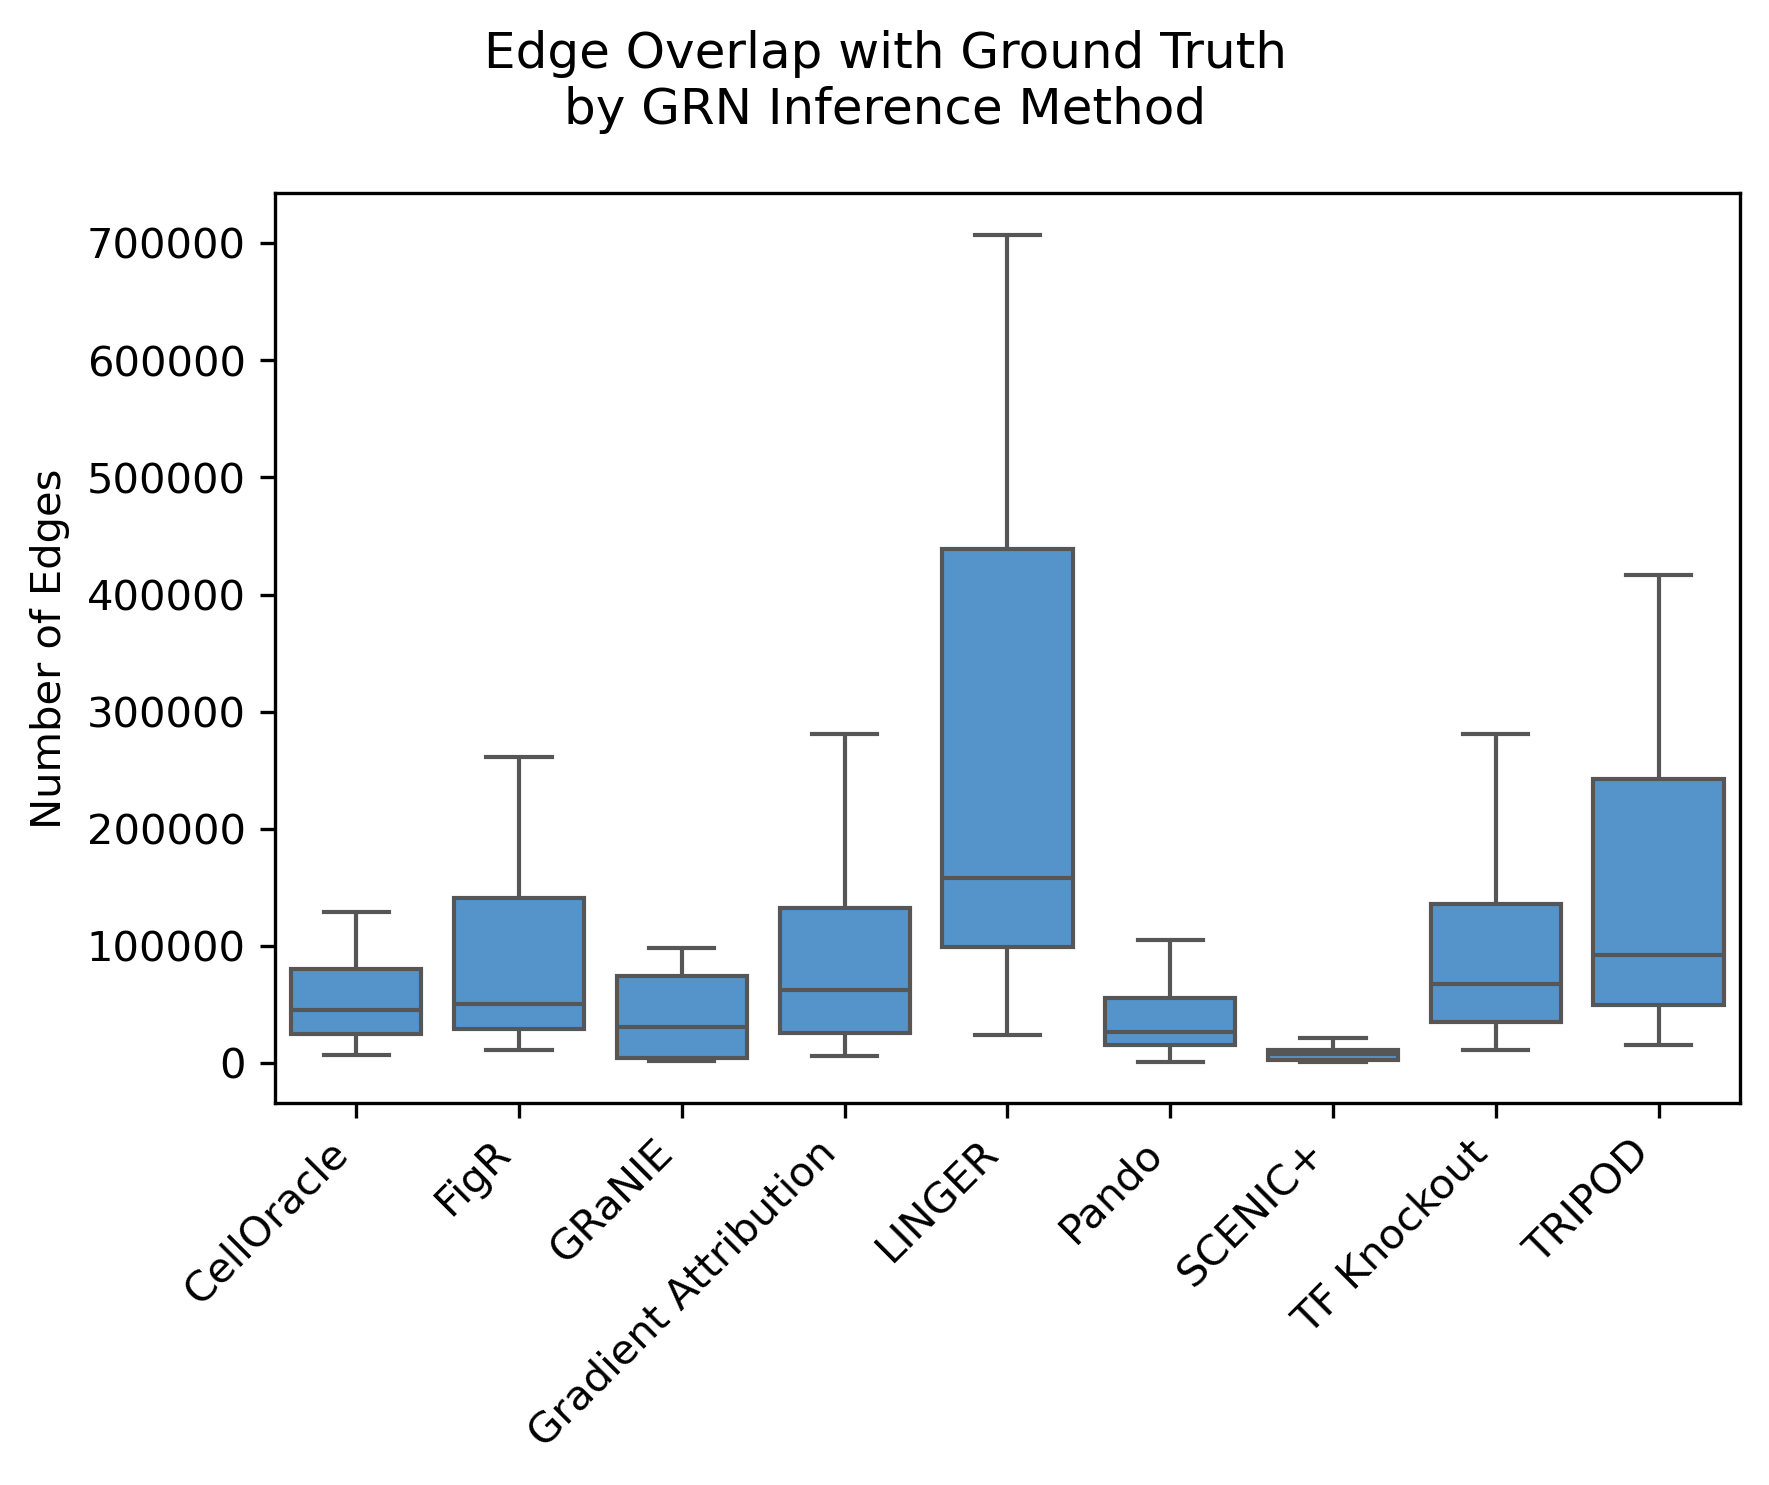

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import set_matplotlib_formats

%config InlineBackend.figure_formats = ['png']
set_matplotlib_formats('retina')

fig = plt.figure(figsize=(6, 5))

ax = sns.boxplot(data=grn_overlap, x="Method", y="Num Edges in GT", showfliers=False, color="#4195df")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set(xlabel=None, ylabel="Number of Edges")
ax.ticklabel_format(style='plain', axis='y')

plt.suptitle("Edge Overlap with Ground Truth\nby GRN Inference Method")
plt.tight_layout()
fig.show()

In [105]:
grn_overlap.to_csv("dev/grn_size_and_gt_overlap_comparison.csv", index=False)